In [1]:
import jax

# jax.config.update("jax_enable_x64", False)
jax.config.update("jax_enable_x64", True)
# jax.config.update("jax_platform_name", "cpu")
jax.config.update("jax_platform_name", "gpu")
jax.config.update("jax_debug_nans", True)
print(jax.local_devices()[0].device_kind)
from jax import numpy as np, random as jr, tree as jtu
import os


import zodiax as zdx
from zodiax.optimisation import sgd, adam
import dLux.utils as dlu

from amigo.fitting import Trainer
import dorito


# visualisation
import matplotlib.pyplot as plt
import matplotlib as mpl
import ehtplot
import scienceplots
import cmasher as cmr

# matplotlib parameters
plt.style.use(["science", "bright", "no-latex"])

plt.rcParams["image.cmap"] = "inferno"
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = "lower"
plt.rcParams["figure.dpi"] = 300
plt.rcParams["font.size"] = 8
plt.rcParams["xtick.direction"] = "out"
plt.rcParams["ytick.direction"] = "out"

inferno = mpl.colormaps["inferno"]
viridis = mpl.colormaps["viridis"]
seismic = mpl.colormaps["seismic"]
coolwarm = mpl.colormaps["coolwarm"]

inferno.set_bad("k", 0.5)
viridis.set_bad("k", 0.5)
seismic.set_bad("k", 0.5)
coolwarm.set_bad("k", 0.5)

NVIDIA GeForce RTX 2080 Ti


In [2]:
from socket import gethostname

if gethostname() == "glinton":
    morgana = "/media/morgana1/"
else:
    morgana = "/Volumes/morgana1/"

data_path = os.path.join(morgana, "snert/max/data/JWST/WR137/calslope/")
uncal_path = os.path.join(morgana, "snert/max/data/JWST/WR137/uncal/")
amigo_cache = os.path.join(morgana, "snert/max/data/amigo_files/")

cache = os.path.join(amigo_cache, "cal_files/")
output_path = os.path.join(amigo_cache, "outputs/WR137/")

load_dict = lambda x: np.load(x, allow_pickle=True).item()
cal_vis_outputs = load_dict(os.path.join(output_path, "cal_vis.npy"))

print(cal_vis_outputs.keys())

dict_keys(['F380M_189.8', 'F380M_162.7', 'F480M_189.8', 'F480M_162.7'])


In [3]:
import amigo


class UniqueOiFit(dorito.model_fits.ResolvedOIFit):

    # def get_key(self, param):

    #     match param:
    #         case "log_dist":
    #             return self.key

    #     return super().get_key(param)

    def rotate(self, model, distribution, clip=True):
        """
        Rotate the distribution by the parallactic angle.
        """
        knots = dlu.pixel_coords(distribution.shape[0], 1.0)
        samps = dlu.rotate_coords(knots, dlu.deg2rad(self.parang))

        distribution = amigo.misc.interp(
            distribution,
            knots,
            samps,
            method="cubic",
        )

        # clipping to enforce positivity
        if clip:
            return np.clip(distribution, min=0.0, max=None)

        return distribution

    # def __call__(self, model, rotate=True):
    #     """
    #     Call the model with the given parameters.
    #     """
    #     # NOTE: Distribution must be odd number of pixels in one axis
    #     distribution = model.get_distribution(self)

    #     # if rotate:
    #     #     distribution = self.rotate(model, distribution)

    #     # distribution /= distribution.sum()  # Normalise the distribution

    #     return self.model_sicko(model, distribution=distribution)

In [ ]:
optics_diameter = 6.603464  # JWST aperture diameter in meters
otf_coords = dlu.pixel_coords(51, 2 * optics_diameter)

ois = [
    UniqueOiFit(oi_data, key, filter=key[:5])
    for key, oi_data in cal_vis_outputs.items()
]
for oi in ois:
    print(oi.key)

# ois = ois[2:]
# ois = [ois[-1]]

# distribution = np.zeros((41, 41)).at[20, 20].set(1.0)  # + 1e-16
# distribution = np.ones((51, 51))
distribution = np.ones((51, 51))
# distribution = np.zeros((51, 51)).at[25, 25].set(1.0) + 1e-2

model = dorito.models.ResolvedSickoModel(
    ois,
    distribution,
    uv_npixels=2 * otf_coords.shape[-1],
    uv_pscale=0.5 * np.diff(otf_coords[0, 0]).mean(),
    # oversample=6.0,
    oversample=6.0,
)

# Initialise at the mean dirty image
params = {"log_dist": {}, "base_uv": model.params["base_uv"]}
hypot = lambda x: np.sqrt(np.array([_x**2 for _x in x]).sum(0))
for filt in ["F380M", "F480M"]:
    dirty_imgs = [oi.dirty_image(model) for oi in ois if oi.filter == filt]

    if dirty_imgs == []:
        print(f"No dirty images for filter {filt}, skipping initialisation.")
        continue
    mean_dirty = hypot(dirty_imgs)
    init_dist = np.log10(mean_dirty / mean_dirty.sum() + 1e-8)
    for oi in ois:
        if oi.filter == filt:
            params["log_dist"][oi.get_key("log_dist")] = init_dist

model = model.set("params", params)

F380M_189.8
F380M_162.7
F480M_189.8
F480M_162.7


In [ ]:
import jax.scipy as jsp
import jax.random as jr


def difflim_to_cov(model, exposure, factor):

    # calculating lambda over D
    D = 6.603464  # m
    lambda_on_D = dlu.rad2arcsec(exposure.wavel / D)

    # calculating sigma, with some factor in front of lambda on D
    sigma = dorito.misc.fwhm_to_sigma(factor * lambda_on_D)

    # return covariance matrix
    return [[sigma**2, 0], [0, sigma**2]]


def blur_distribution(array, model, exposure, extent=0.25, factor=1.0):
    cov = difflim_to_cov(model, exposure, factor)

    x = np.arange(-extent, extent, dlu.rad2arcsec(model.pscale_in))
    X, Y = np.meshgrid(x, x)
    pos = np.dstack((X, Y))

    kernel = jsp.stats.multivariate_normal.pdf(jr.PRNGKey(0), pos, np.array(cov))

    distribution = jsp.signal.convolve2d(
        array,
        kernel,
        mode="same",
        # method="fft",
    )
    return distribution / distribution.sum()


# def normalise_distribution(model_params, args):
#     params = model_params.params
#     if "log_dist" in params.keys():
#         for k, log_dist in params["log_dist"].items():
#             distribution = 10**log_dist
#             params["log_dist"][k] = np.log10(distribution / distribution.sum())

#     return model_params.set("params", params), args


def normalise_distribution(model_params, args):
    params = model_params.params

    if "log_dist" in params.keys():
        for k, log_dist in params["log_dist"].items():
            distribution = 10**log_dist

            # centre = distribution.shape[0] // 2
            # norm = distribution[centre, centre]

            norm = distribution.sum()

            params["log_dist"][k] = np.log10(distribution / norm)

    return model_params.set("params", params), args


# def grad_fn(model, grads, args):

#     threshold = 1e-5

#     params = grads.params
#     if "log_dist" in params.keys():
#         for k, grad in params["log_dist"].items():
#             grad = np.clip(grad, threshold, threshold)
#             params["log_dist"][k] = grad

#     return grads.set("params", params), args


def looper(looper, loss_dict):
    loss = np.array([v[-1] for v in loss_dict.values()]).mean(0)
    looper.set_description(f"Loss: {loss:.3e}")


def log_likelihood(model, oi, args={}):
    data = np.concatenate([oi.vis, oi.phi])
    err = np.concatenate([oi.d_vis, oi.d_phi])
    model_vis = np.concatenate([*oi(model)])  # same shape as data

    residual = data - model_vis
    nll = np.sum(0.5 * (residual / err) ** 2 + np.log(err * np.sqrt(2 * np.pi)))

    return nll


def apply_regularisers(model, exposure, args):
    # creating a list of regularisation functions and regularisation hyperparameters
    fn_list = [args["reg_func_dict"][reg] for reg in args["reg_dict"].keys()]
    coeff_list = list(args["reg_dict"].values())

    # evaluating the regularisation term with each for each regulariser
    priors = [
        coeff * fn(model, exposure, args) for coeff, fn in zip(coeff_list, fn_list)
    ]
    prior = np.array(priors).sum()  # summing the different regularisers

    return prior


def calc_loglike_prior(model, exposure, args):
    # this is per exposure

    # regular likelihood term
    likelihood = np.nanmean(log_likelihood(model, exposure))

    # grabbing and exponentiating log distributions
    prior = apply_regularisers(model, exposure, args)

    return likelihood, prior


def regularised_loss_fn(model, exposure, args={"reg_func_dict": {}, "reg_dict": {}}):
    # this is per exposure
    likelihood, prior = calc_loglike_prior(model, exposure, args)
    return likelihood + prior, ()
    # return likelihood + prior


def phase_centre(model, oi, args={}):

    distribution = model.get_distribution(oi)

    # Tip/Tilt vectors (ramp in u,v)
    mu = oi.u / np.linalg.norm(oi.u)
    mv = oi.v / np.linalg.norm(oi.v)

    # to log visibilities
    _log_amp, phase = oi.to_logvis(model, distribution)

    # calculating the phase centre of the distribution
    return np.hypot(np.dot(mu, phase), np.dot(mv, phase))


def centered_loss_fn(model, exposure, args, width=1e-3):
    likelihood, prior = calc_loglike_prior(model, exposure, args)

    # phase centre prior
    centre = phase_centre(model, exposure, args)
    prior += -jax.scipy.stats.norm.logpdf(centre, loc=0.0, scale=width)

    return likelihood + prior, ()

In [ ]:
jax.config.update("jax_debug_nans", True)

n_epoch = 8000

config = {
    # "log_dist": sgd(1e-8, 0, (1000, 0.1)),
    # "log_dist": sgd(3e-800, 0),
    # "log_dist": optax.sgd(1e-8, 0),
    # "log_dist": sgd(5e-8, 0)  # (100, 10), (2000, 0.5)),
    "log_dist": adam(1e-2, 0, (5000, 0.5)),
    # "log_dist": sgd(5e-9, 0, (500, 2), (1000, 2)),
    # "log_dist": sgd(1e-8, 0, (10, 5), (500, 0.25), (1000, 1.5), (1300, 0.75)),
}

args = {
    "reg_func_dict": {
        "ME": dorito.stats.ME,
        "TV": dorito.stats.TV,
        "L2": dorito.stats.L2,
        "TSV": dorito.stats.TSV,
    },
    "reg_dict": {
        "ME": 1e5,
        # "ME": 1e5,
        # "TV": 1.0,
        # "L2": 1e-5,
        # "TSV": 5e6,
    },
}

# trainer = Trainer(
#     # trainer = Trainer(
#     # loss_fn=regularised_loss_fn,
#     loss_fn=centered_loss_fn,
#     # cache=fisher_cache,
#     # grad_fn=grad_fn,
#     norm_fn=normalise_distribution,
#     looper_fn=looper,
# )

# trainer = trainer.update_fishers(
#     model=model,
#     exposures=[],
#     parameters=[],
# )

# # Train the model
# result = trainer.train(
#     model=model,
#     optimisers=config,
#     epochs=n_epoch,
#     batches=ois,
#     args=args,
#     # batches=exposures,
# )

In [ ]:
# from amigo import plotting

# for oi in ois:
#     dist = 10 ** result.model.params["log_dist"][oi.get_key("log_dist")]

#     sicko_amp, sicko_phase = oi(result.model)

#     fig, ax = plt.subplots(1, 2, figsize=(9, 3), sharey=False)

#     ax[0].errorbar(
#         sicko_amp,
#         oi.vis,
#         yerr=oi.d_vis,
#         label="Amplitude Correlations",
#         fmt="x",
#         alpha=0.3,
#         color="midnightblue",
#     )
#     x_min, x_max = ax[0].get_xlim()
#     y_min, y_max = ax[0].get_ylim()
#     min_val = min(x_min, y_min)
#     max_val = max(x_max, y_max)
#     ax[0].plot([min_val, max_val], [min_val, max_val], "r--", label="y=x")
#     ax[0].set_title("Amplitude Correlations")
#     ax[0].set_xlabel("Reconstructed Sicko Amplitude")
#     ax[0].set_ylabel("Calibrated Sicko Amplitude")
#     ax[0].legend()

#     ax[1].errorbar(
#         sicko_phase,
#         oi.phi,
#         yerr=oi.d_phi,
#         label="Phase Correlations",
#         fmt="x",
#         alpha=0.3,
#         color="indigo",
#     )
#     x_min, x_max = ax[1].get_xlim()
#     y_min, y_max = ax[1].get_ylim()
#     min_val = min(x_min, y_min)
#     max_val = max(x_max, y_max)
#     ax[1].plot([min_val, max_val], [min_val, max_val], "r--", label="y=x")
#     ax[1].set_title("Phase Correlations")
#     ax[1].set_xlabel("Reconstructed Sicko Phase")
#     ax[1].set_ylabel("Calibrated Sicko Phase")
#     ax[1].legend()

#     plt.tight_layout()
#     plt.show()

#     ticks = [-0.5, -0.25, 0, 0.25, 0.5]

#     fig, ax = plt.subplots(1, 2, figsize=(6, 2.3))

#     c0 = dorito.plotting.plot_result(
#         ax[0],
#         dist,
#         pixel_scale=dlu.rad2arcsec(model.pscale_in),
#         cmap="afmhot_10u",
#         power=0.3,
#         vmin=0,
#         ticks=ticks,
#     )
#     # ax[0].scatter([0], [0], marker="^", color="skyblue", s=1)

#     c1 = dorito.plotting.plot_result(
#         ax[1],
#         blur_distribution(dist, model, oi, factor=0.5),
#         pixel_scale=dlu.rad2arcsec(model.pscale_in),
#         cmap="afmhot_10u",
#         power=0.3,
#         vmin=None,
#         ticks=ticks,
#     )
#     ax[1].scatter([0], [0], marker="^", color="skyblue", s=1)
#     fig.colorbar(c1, ax=ax[1])

#     fig.colorbar(c0)
#     # pa = model.params["position_angles"][exp.key]
#     ax[0].set_title(
#         f"WR137 - {oi.key}"  # - {model.params['position_angles'][exp.get_key('position_angles')]:.1f}deg"
#     )
#     ax[1].set(title=r"Convolved - $\lambda / 2D$")

#     plt.tight_layout()
#     # plt.savefig(output_path + f"{time}.png", dpi=300)
#     # plt.close()
#     plt.show()

# plotting.plot_losses(result.losses[0], start=int(n_epoch * 0.75))
# # plotting.plot(result.history)

In [ ]:
import equinox as eqx
import optimistix as optx


def BFGS_logdist(
    model,
    exposures,
    reg_args,
    Solver=optx.BFGS,
    max_steps=2**16,
    rtol=1e-4,
    atol=1e-4,
):

    @eqx.filter_jit
    def fun(y, args):

        # unwrapping the args
        model, exp, reg_args = args

        # input is the log distribution
        log_dist = y

        # setting the model to the new log distribution
        params = model.params
        params["log_dist"][exp.get_key("log_dist")] = log_dist
        model = model.set("params", params)

        # calculating loss
        loss, _ = regularised_loss_fn(model, exp, reg_args)

        sum_prior = -jax.scipy.stats.norm.logpdf(
            model.get_distribution(exp).sum(), loc=1.0, scale=1e-5
        )

        return loss + sum_prior

    args_out = {}
    sols_out = {}
    for exp in exposures:

        X = model.params["log_dist"][exp.get_key("log_dist")]
        args = (model, exp, reg_args)
        args_out[exp.key] = args

        print("Initial loss:", fun(X, args))
        solver = Solver(rtol=rtol, atol=atol)  # , verbose=frozenset({"loss"}))
        sol = optx.minimise(fun, solver, X, args, throw=False, max_steps=max_steps)
        sols_out[exp.key] = sol

        print("Final loss:", fun(sol.value, args))
        print(sol.stats["num_steps"], sol.state.num_accepted_steps)
        print(optx.RESULTS[sol.result])
        print()

    params = model.params
    for exp in ois:
        log_dist = sols_out[exp.key].value
        params["log_dist"][exp.get_key("log_dist")] = log_dist

    return model.set("params", params)


def joint_solve(
    model,
    exposures,
    reg_args,
    Solver=optx.BFGS,
    max_steps=2**16,
    rtol=1e-4,
    atol=1e-4,
):

    @eqx.filter_jit
    def fun(y, args):

        # unwrapping the args
        model, exps, reg_args = args

        # input is the log distribution
        log_dist = y

        # setting the model to the new log distribution
        params = model.params
        params["log_dist"][exps[0].get_key("log_dist")] = log_dist
        model = model.set("params", params)

        # calculating loss
        loss = [centered_loss_fn(model, exp, reg_args)[0] for exp in exps]
        loss = np.array(loss).mean()

        sum_prior = -jax.scipy.stats.norm.logpdf(
            model.get_distribution(exps[0]).sum(), loc=1.0, scale=1e-5
        )

        return loss + sum_prior

    args_out = {}
    sols_out = {}

    for filt in ["F380M", "F430M", "F480M"]:

        exps = [oi for oi in exposures if oi.filter == filt]
        for exp in exps:
            print(exp.key)

        if len(exps) == 0:
            print(f"No exposures for filter {filt}, skipping initialisation.")
            continue

        X = model.params["log_dist"][filt]
        _args = (model, exps, reg_args)
        args_out[filt] = _args

        print("Initial loss:", fun(X, _args))
        solver = Solver(rtol=rtol, atol=atol, verbose=frozenset({"loss"}))
        sol = optx.minimise(fun, solver, X, _args, throw=False, max_steps=max_steps)
        sols_out[filt] = sol

        print("Final loss:", fun(sol.value, _args))
        print(sol.stats["num_steps"], sol.state.num_accepted_steps)
        print(optx.RESULTS[sol.result])
        print()

    params = {"log_dist": {}, "base_uv": model.params["base_uv"]}
    for exp in ois:
        log_dist = sols_out[exp.filter].value
        params["log_dist"][exp.get_key("log_dist")] = log_dist

    return model.set("params", params)

In [ ]:
# final_model = result.model


bfgs_model = BFGS_logdist(
    # final_model,
    model,
    ois,
    args,
    Solver=optx.LevenbergMarquardt,
    max_steps=2**16,
    rtol=1e-6,
    atol=1e-6,
)


# bfgs_model = joint_solve(
#     model,
#     # final_model,
#     ois,
#     args,
#     Solver=optx.LevenbergMarquardt,
#     max_steps=2**14,
#     rtol=1e-6,
#     atol=1e-6,
# )

# for oi in ois:
#     sol = sols_out[oi.filter]
#     print(oi.key)
#     print("Final loss:", fun(sol.value, _args))
#     # print(sol.result)

Initial loss: 59971929.36325424


2025-05-30 17:28:39.374105: W external/xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 25.57GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.


XlaRuntimeError: RESOURCE_EXHAUSTED: Out of memory while trying to allocate 27454713984 bytes.

In [ ]:
# np.save("files/71pix_os5.npy", bfgs_model.params, allow_pickle=True)
# np.save(output_path + "71pix_os5.npy", bfgs_model.params, allow_pickle=True)
# np.save(output_path + "121pix_os8.npy", bfgs_model.params, allow_pickle=True)

# params = np.load(output_path + "121pix_os8.npy", allow_pickle=True).item()
# bfgs_model = model.set("params", params)

In [ ]:
oi.parang

Array(162.70743146, dtype=float64)

1.000059963992462
0.00016538479265898928
Loss: -3.664e+05


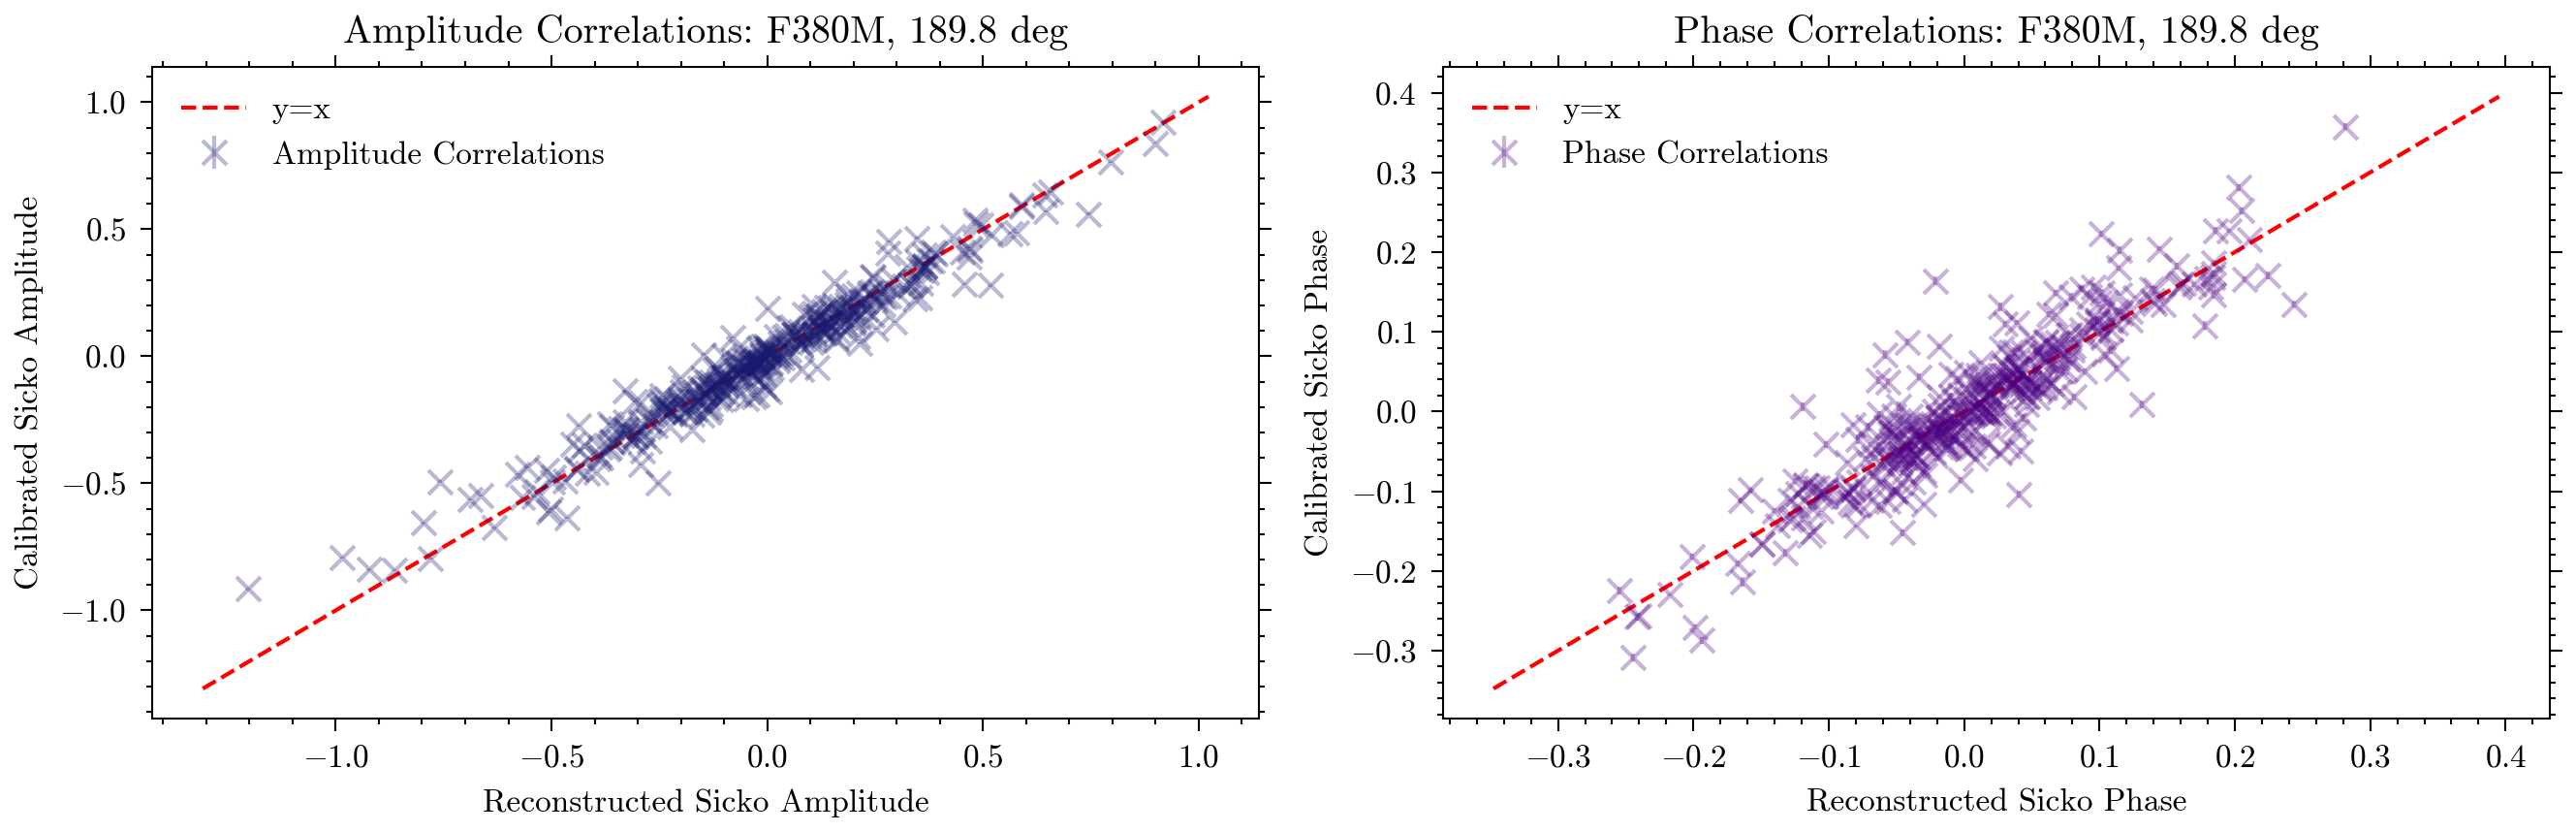

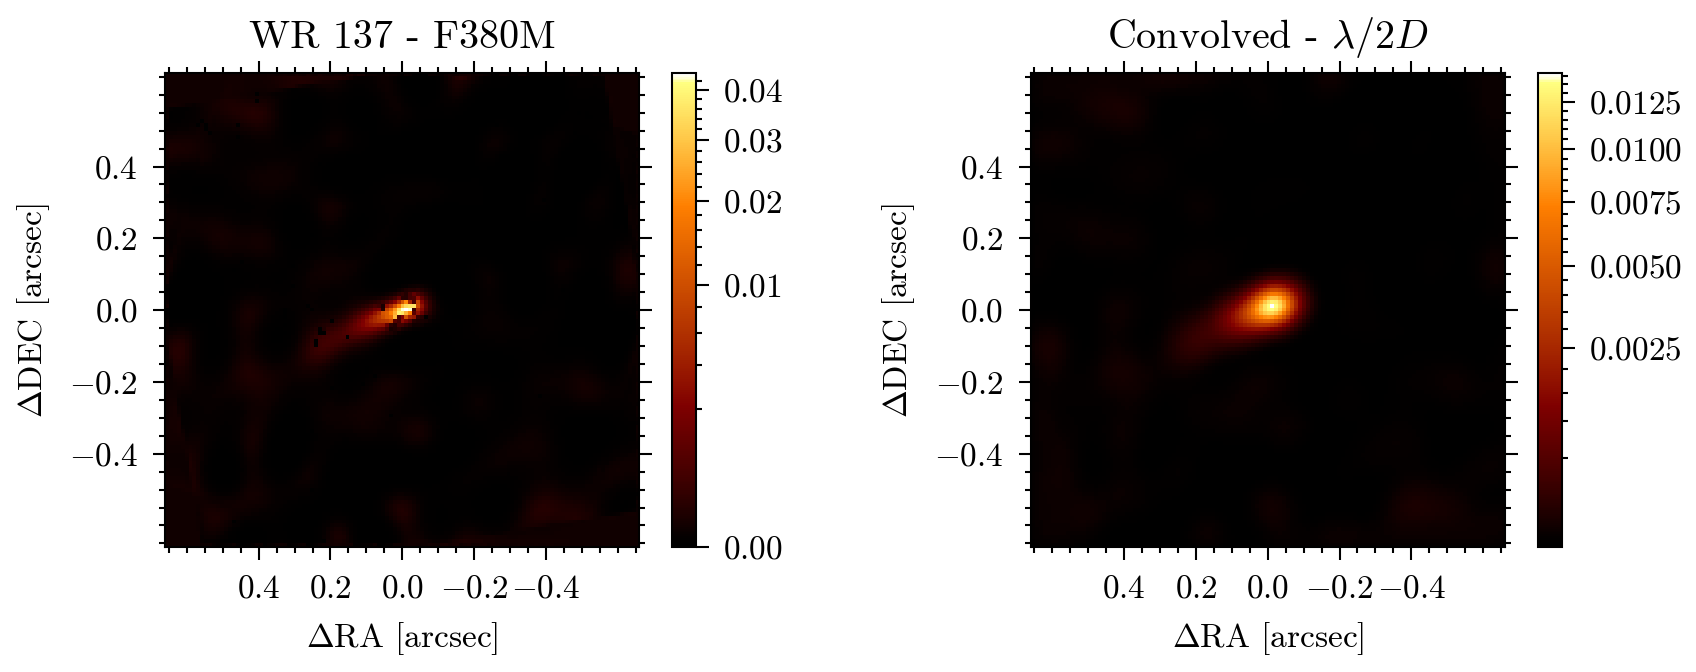

1.000059963992462
0.00016538479265903222
Loss: -4.621e+05


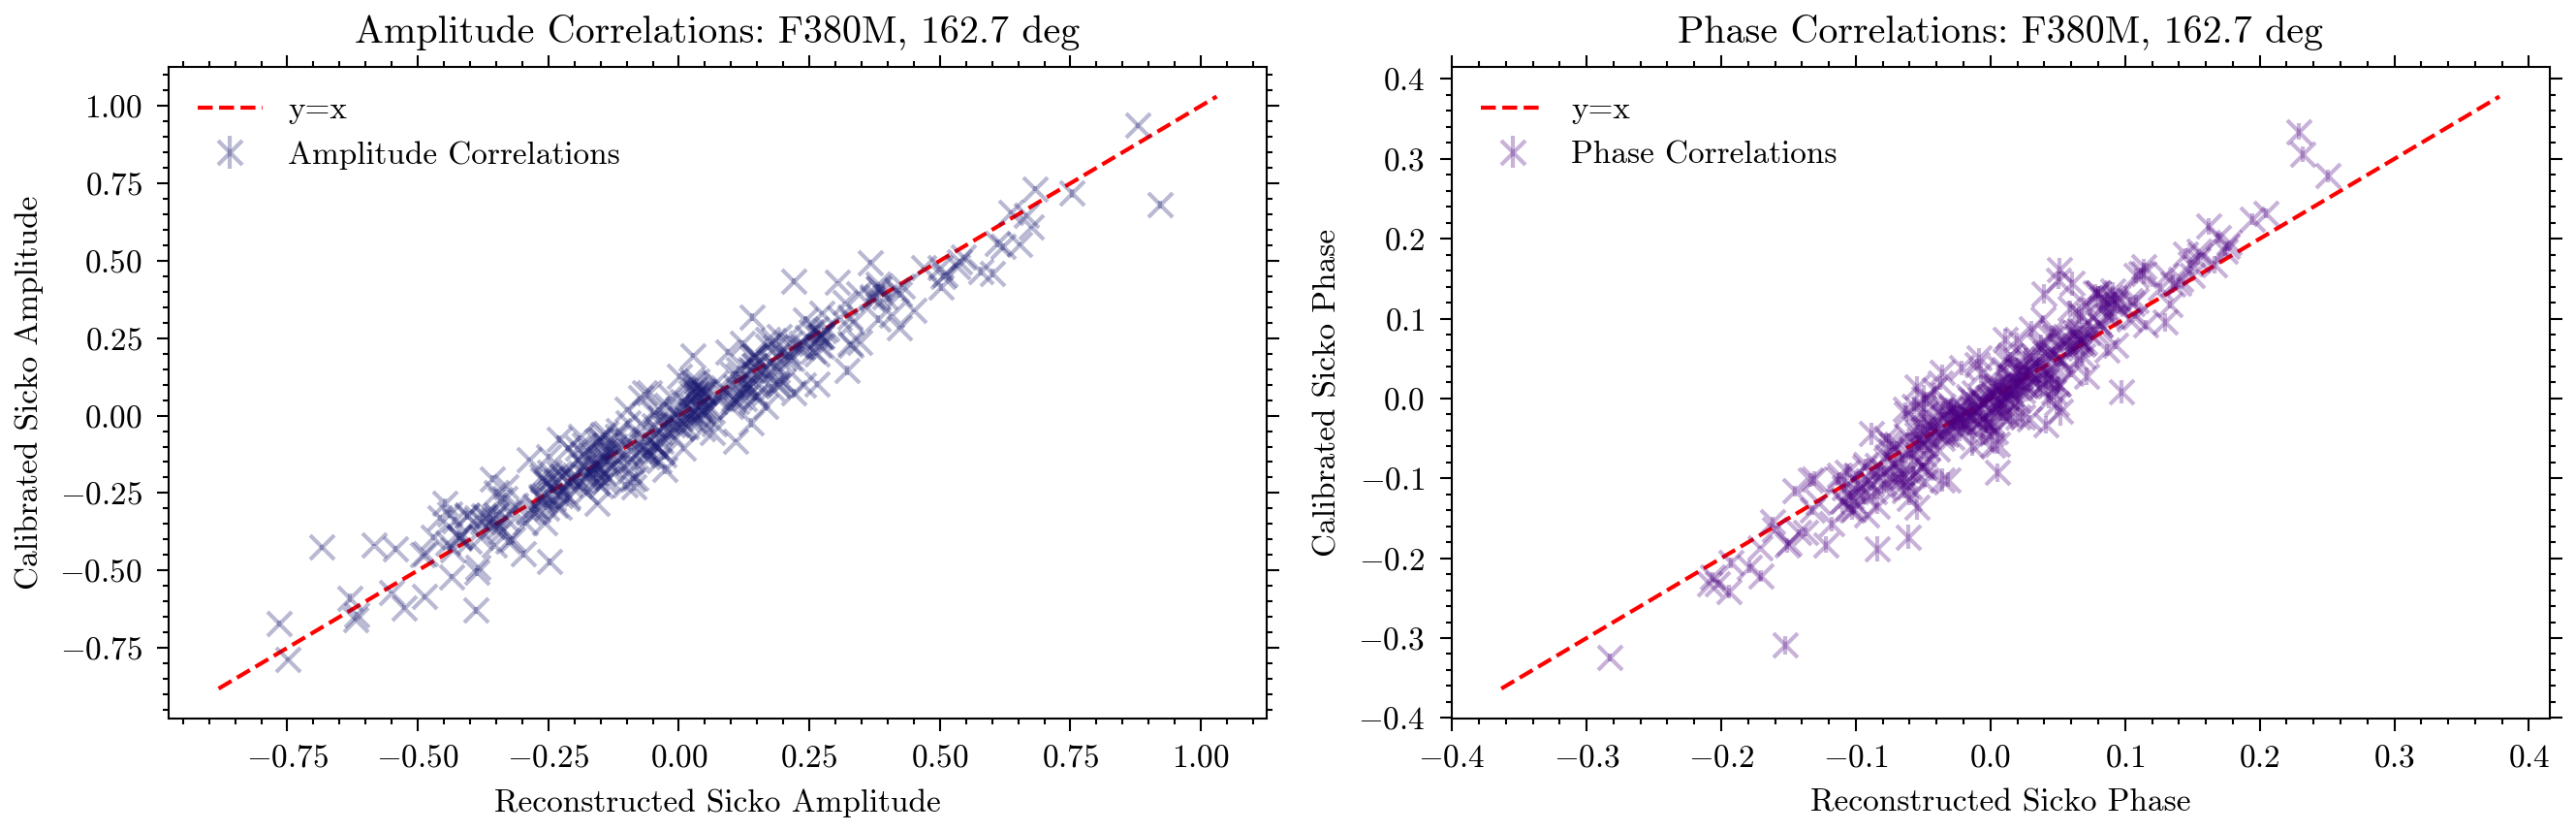

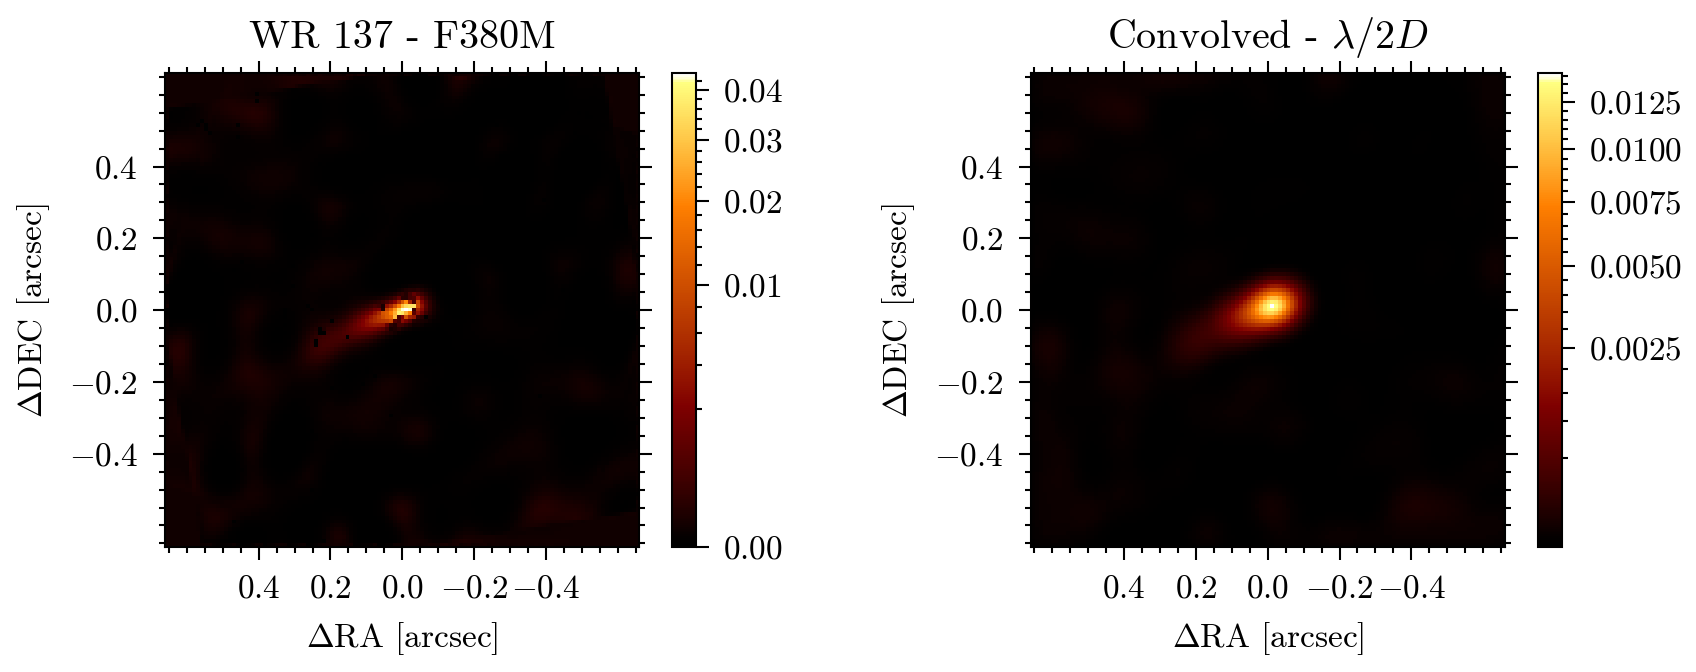

1.0000502370593205
0.00044587957877933646
Loss: -4.317e+05


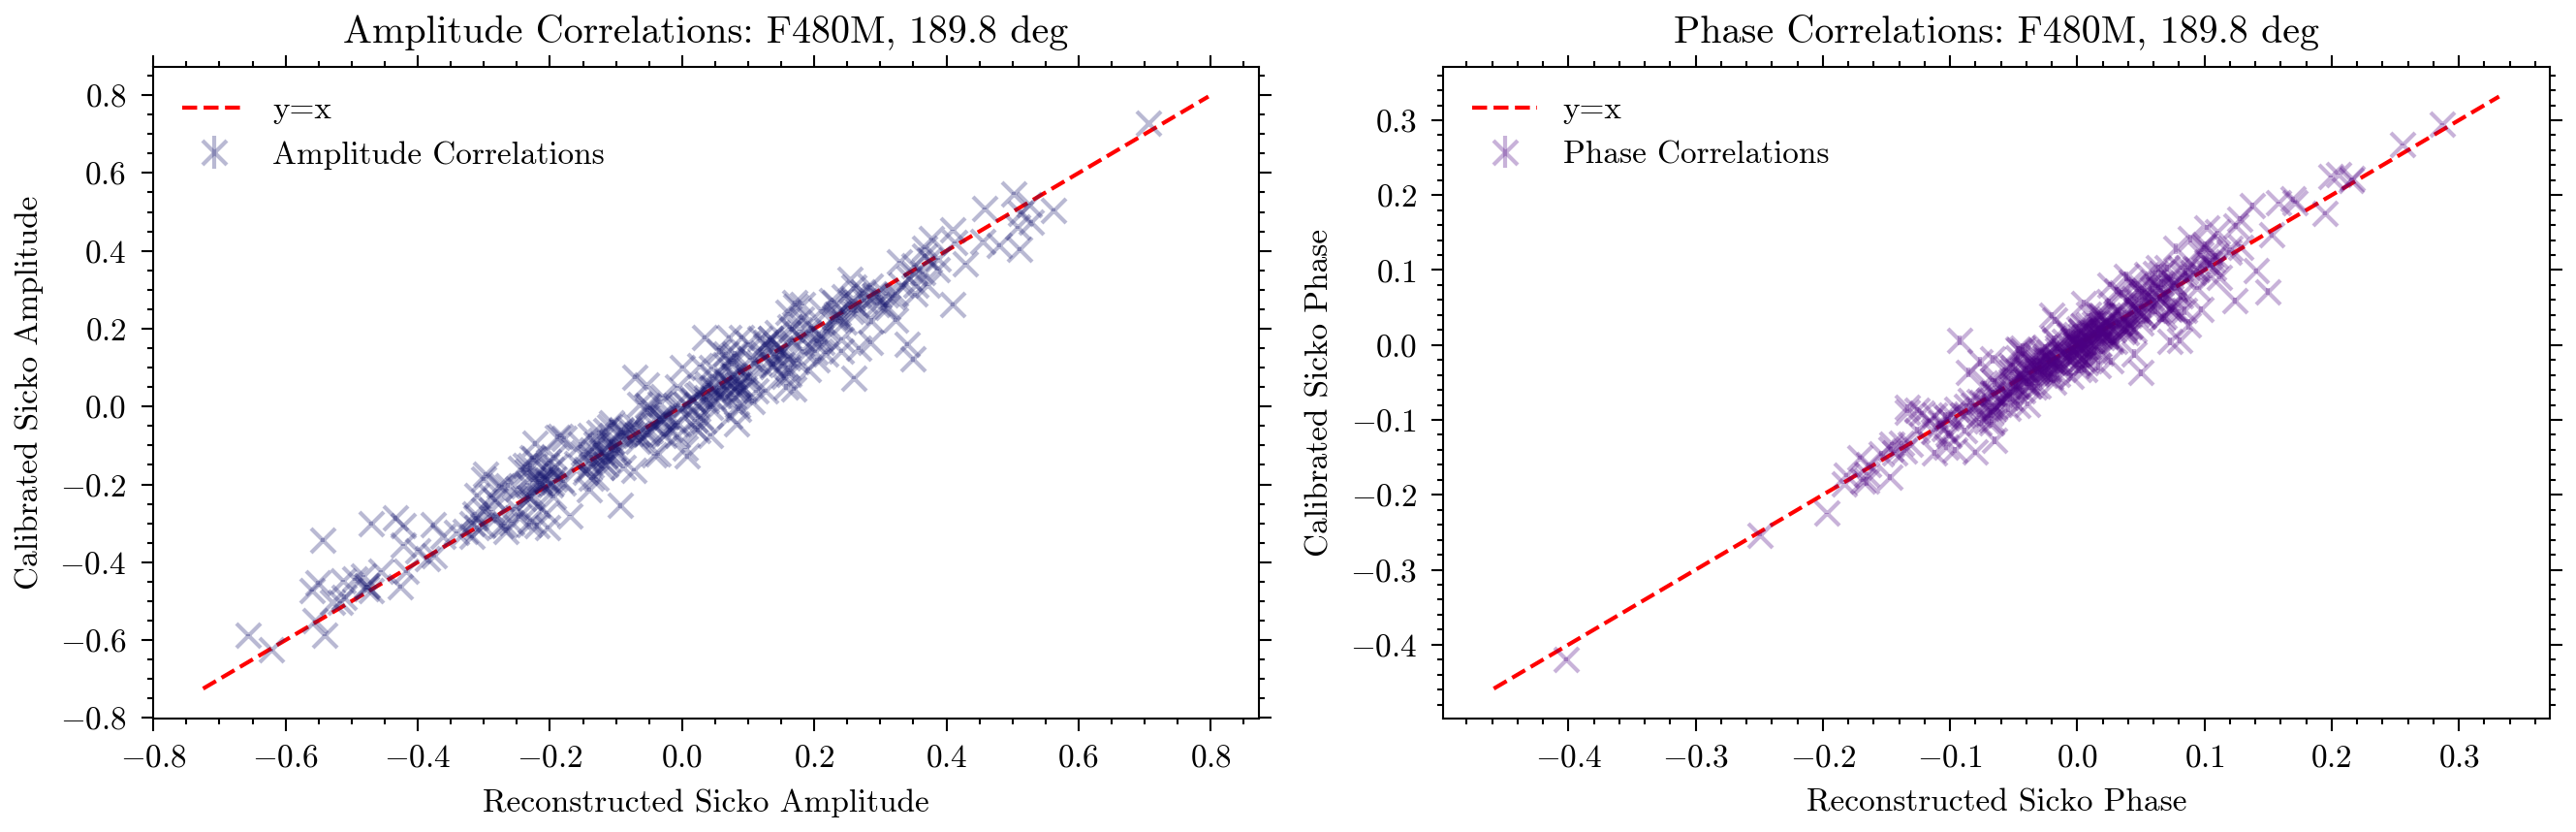

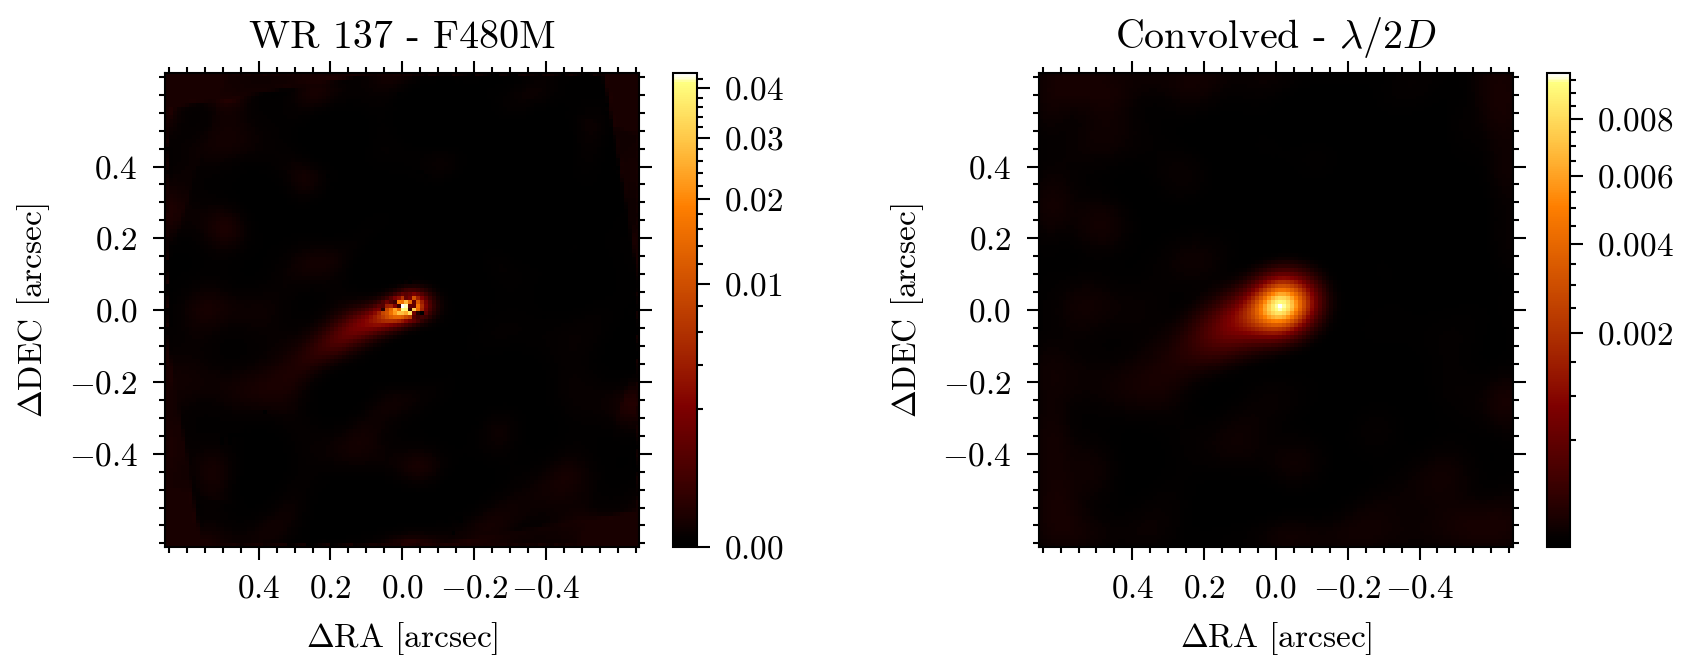

1.0000502370593205
0.0004458795787793421
Loss: -4.963e+05


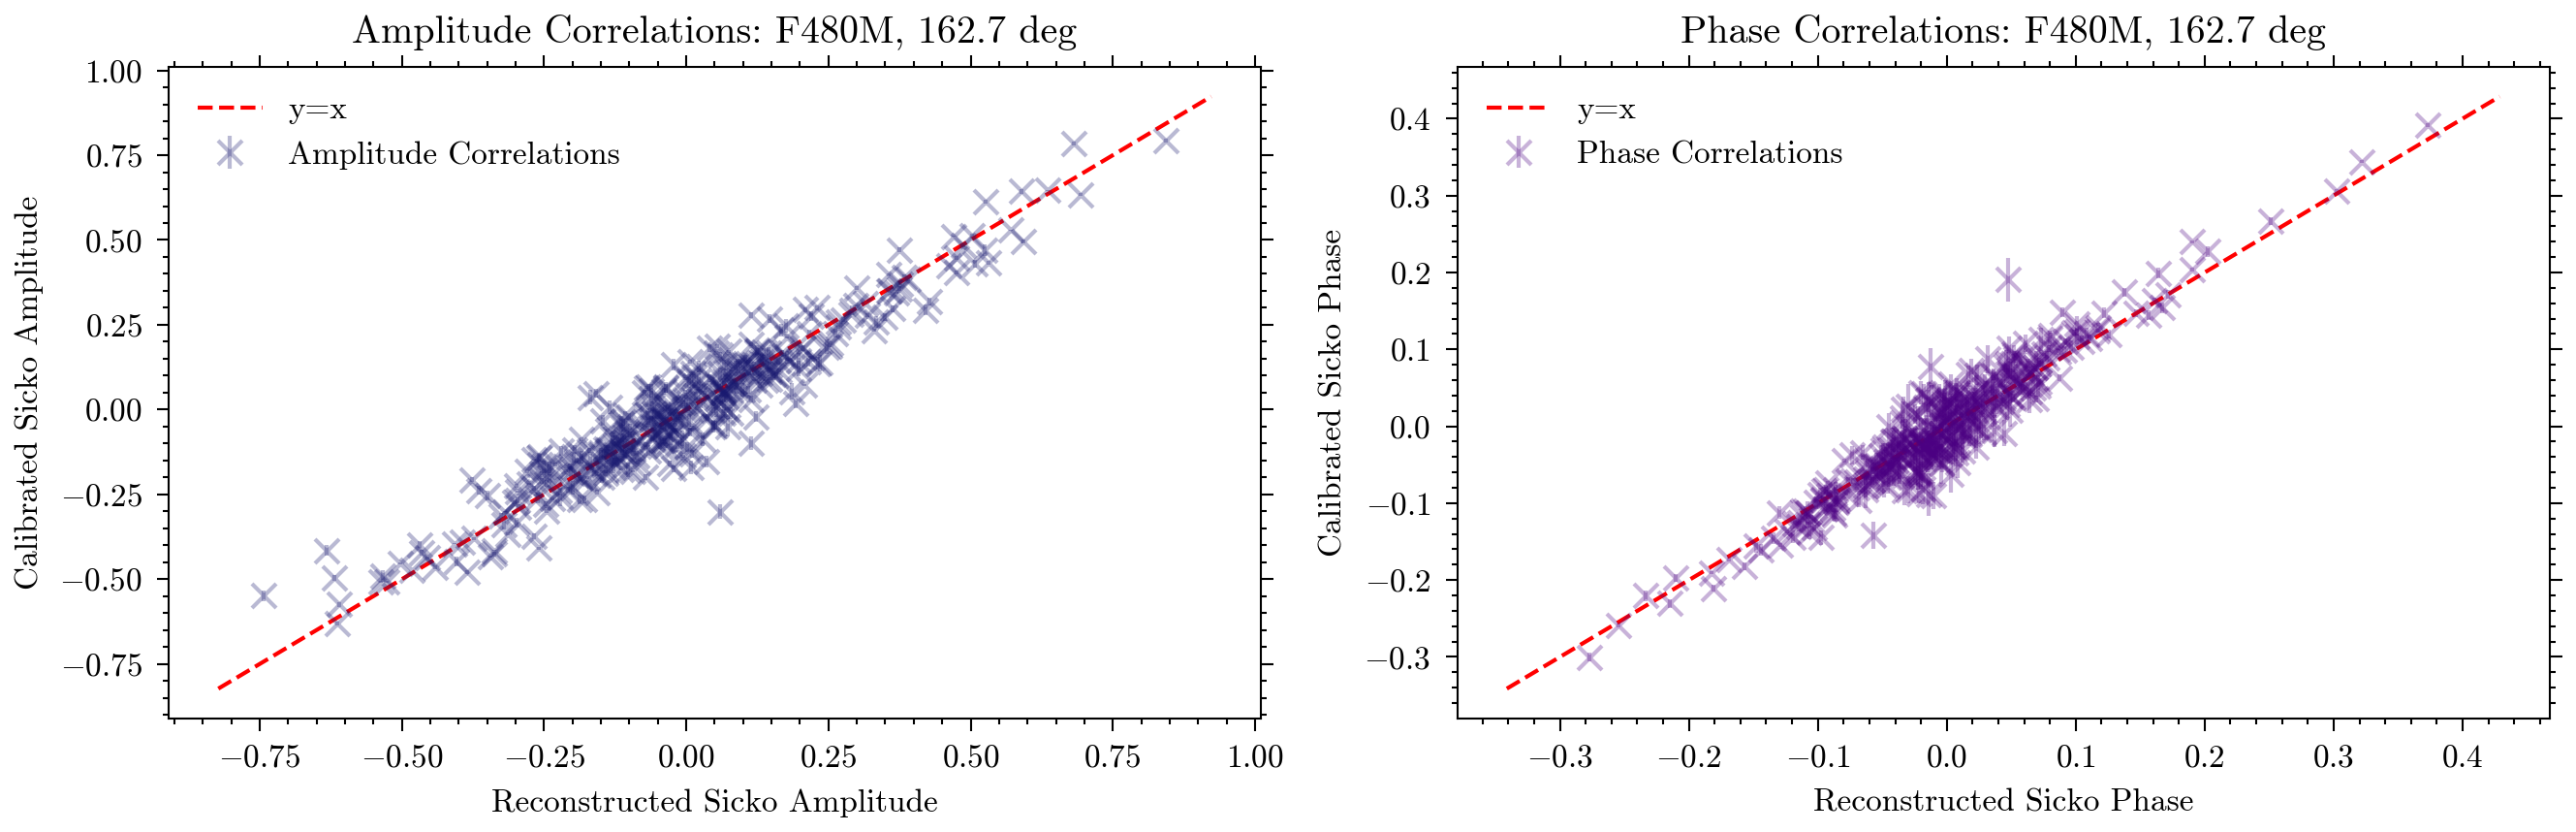

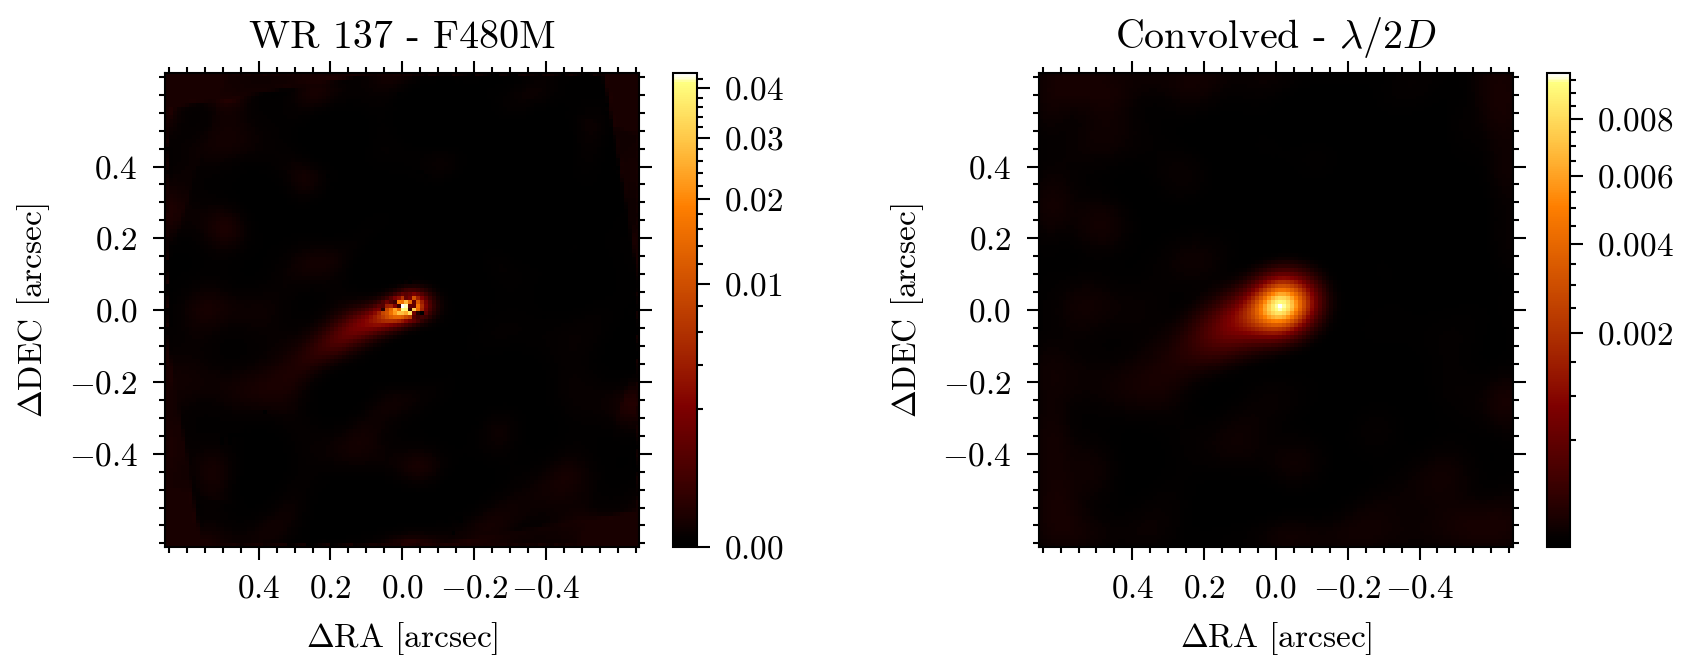

In [ ]:
for oi in ois:

    print(bfgs_model.get_distribution(oi).sum())
    print(phase_centre(bfgs_model, oi))
    loss = centered_loss_fn(bfgs_model, oi, args)[0]
    print(f"Loss: {loss:.3e}")

    dist = 10 ** bfgs_model.params["log_dist"][oi.get_key("log_dist")]

    sicko_amp, sicko_phase = oi(bfgs_model)

    fig, ax = plt.subplots(1, 2, figsize=(9, 3), sharey=False)

    ax[0].errorbar(
        sicko_amp,
        oi.vis,
        yerr=oi.d_vis,
        label="Amplitude Correlations",
        fmt="x",
        alpha=0.3,
        color="midnightblue",
    )
    x_min, x_max = ax[0].get_xlim()
    y_min, y_max = ax[0].get_ylim()
    min_val = min(x_min, y_min)
    max_val = max(x_max, y_max)
    ax[0].plot([min_val, max_val], [min_val, max_val], "r--", label="y=x")
    ax[0].set_title(f"Amplitude Correlations: {oi.filter}, {oi.parang:.1f} deg")
    ax[0].set_xlabel("Reconstructed Sicko Amplitude")
    ax[0].set_ylabel("Calibrated Sicko Amplitude")
    ax[0].legend()

    ax[1].errorbar(
        sicko_phase,
        oi.phi,
        yerr=oi.d_phi,
        label="Phase Correlations",
        fmt="x",
        alpha=0.3,
        color="indigo",
    )
    x_min, x_max = ax[1].get_xlim()
    y_min, y_max = ax[1].get_ylim()
    min_val = min(x_min, y_min)
    max_val = max(x_max, y_max)
    ax[1].plot([min_val, max_val], [min_val, max_val], "r--", label="y=x")
    ax[1].set_title(f"Phase Correlations: {oi.filter}, {oi.parang:.1f} deg")
    ax[1].set_xlabel("Reconstructed Sicko Phase")
    ax[1].set_ylabel("Calibrated Sicko Phase")
    ax[1].legend()

    plt.tight_layout()
    plt.show()

    ticks = [-0.4, -0.2, 0, 0.2, 0.4]

    fig, ax = plt.subplots(1, 2, figsize=(6, 2.3))

    c0 = dorito.plotting.plot_result(
        ax[0],
        dist,
        pixel_scale=dlu.rad2arcsec(model.pscale_in),
        cmap="afmhot_u",
        power=0.4,
        vmin=0,
        ticks=ticks,
    )

    c1 = dorito.plotting.plot_result(
        ax[1],
        blur_distribution(dist, model, oi, factor=0.5),
        pixel_scale=dlu.rad2arcsec(model.pscale_in),
        cmap="afmhot_u",
        power=0.5,
        vmin=None,
        ticks=ticks,
    )
    fig.colorbar(c1, ax=ax[1])

    fig.colorbar(c0)
    # pa = model.params["position_angles"][exp.key]

    ax[0].set_title(
        f"WR 137 - {oi.filter}"  # - {model.params['position_angles'][exp.get_key('position_angles')]:.1f}deg"
    )
    ax[1].set(title=r"Convolved - $\lambda / 2D$")

    plt.tight_layout()
    # plt.savefig(output_path + f"{time}.png", dpi=300)
    # plt.close()
    plt.show()

    # rl_dist = np.clip(dist + 1e-16)
    # rl_dist = rl_dist / rl_dist.max()
    # plt.imshow(rl_dist, norm=mpl.colors.LogNorm(vmin=1e-4, vmax=1.0))
    # plt.colorbar(ticks=[])
    # plt.show()

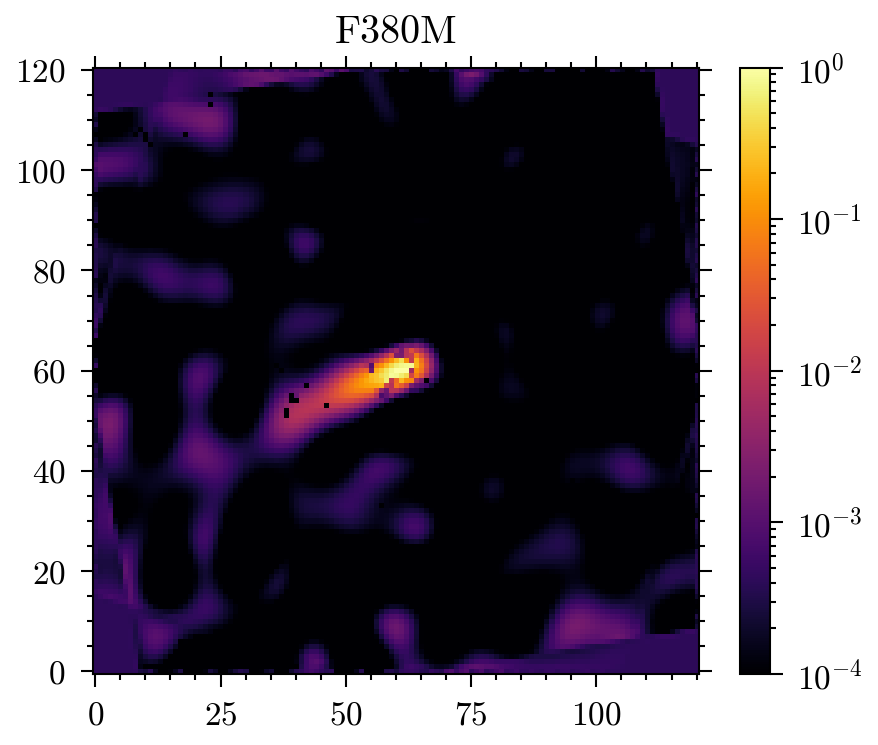

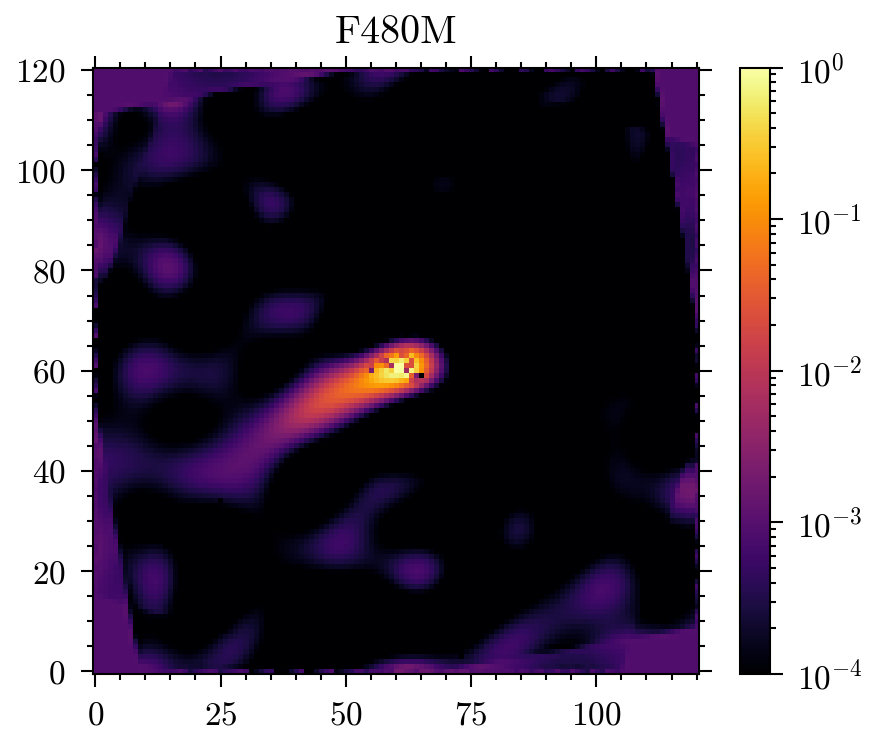

In [ ]:
for filt in ["F380M", "F480M"]:
    dist = 10 ** bfgs_model.params["log_dist"][filt]

    rl_dist = np.clip(dist + 1e-16)
    rl_dist = rl_dist / rl_dist.max()
    plt.imshow(rl_dist, norm=mpl.colors.LogNorm(vmin=1e-4, vmax=1.0))
    plt.title(filt)
    plt.colorbar()
    plt.show()